Dataset:
[[5 8]
 [9 5]
 [0 0]
 [1 7]
 [6 9]
 [2 4]
 [5 2]
 [4 2]
 [4 7]
 [7 9]]
Shape: (10, 2)


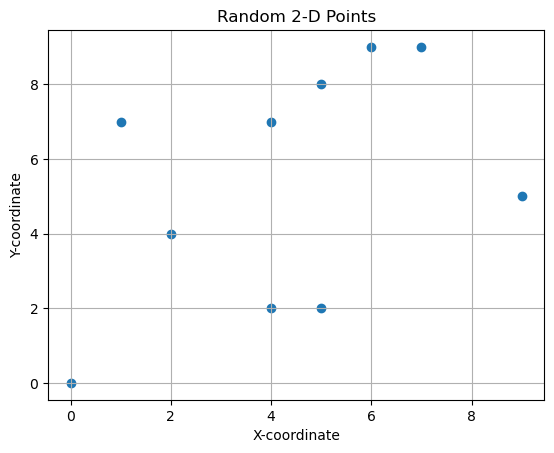

Distance Matrix:
[[  0  25  89  17   2  25  36  37   2   5]
 [ 25   0 106  68  25  50  25  34  29  20]
 [ 89 106   0  50 117  20  29  20  65 130]
 [ 17  68  50   0  29  10  41  34   9  40]
 [  2  25 117  29   0  41  50  53   8   1]
 [ 25  50  20  10  41   0  13   8  13  50]
 [ 36  25  29  41  50  13   0   1  26  53]
 [ 37  34  20  34  53   8   1   0  25  58]
 [  2  29  65   9   8  13  26  25   0  13]
 [  5  20 130  40   1  50  53  58  13   0]]
Shape: (10, 10)
Coordinate differences: (10, 10, 2)
Squared differences: (10, 10, 2)
Distance matrix: (10, 10)
Diagonal values:
[0 0 0 0 0 0 0 0 0 0]
Are all diagonal values zero?
True
Neighbour ordering:
[[0 4 8 9 3 1 5 6 7 2]
 [1 9 0 4 6 8 7 5 3 2]
 [2 5 7 6 3 8 0 1 4 9]
 [3 8 5 0 4 7 9 6 2 1]
 [4 9 0 8 1 3 5 6 7 2]
 [5 7 3 6 8 2 0 4 1 9]
 [6 7 5 1 8 2 0 3 4 9]
 [7 6 5 2 8 1 3 0 4 9]
 [8 0 4 3 5 9 7 6 1 2]
 [9 4 0 8 1 3 5 6 7 2]]
2 Nearest Neighbours:
[[4 8]
 [9 0]
 [5 7]
 [8 5]
 [9 0]
 [7 3]
 [7 5]
 [6 5]
 [0 4]
 [4 0]]
K+1 nearest indices:
[[

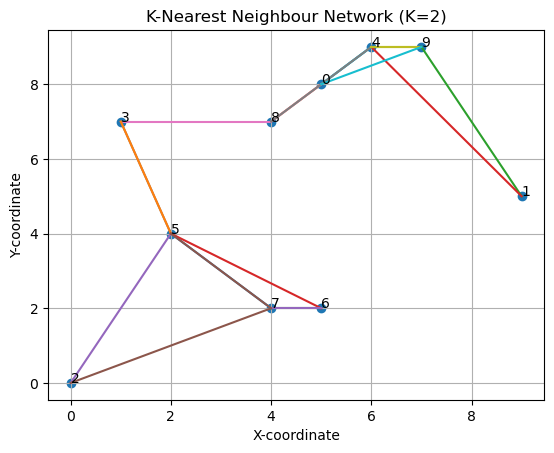

Nearest Neighbours using Loop-Based Method:
[[4 8]
 [9 0]
 [5 7]
 [8 5]
 [9 0]
 [7 3]
 [7 5]
 [6 5]
 [0 4]
 [4 0]]
Nearest Neighbours using Vectorized Method:
[[4 8]
 [9 0]
 [5 7]
 [8 5]
 [9 0]
 [7 3]
 [7 5]
 [6 5]
 [0 4]
 [4 0]]
65.3 ms ± 11.7 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
638 μs ± 80.5 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
4.76 s ± 387 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
84.7 ms ± 2.47 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
2min 8s ± 4.79 s per loop (mean ± std. dev. of 7 runs, 1 loop each)
2.36 s ± 108 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)

X = np.random.randint(10, size=(10,2))

print("Dataset:")
print(X)

print("Shape:", X.shape)

plt.scatter(X[:, 0], X[:, 1])

plt.xlabel("X-coordinate")
plt.ylabel("Y-coordinate")
plt.title("Random 2-D Points")
plt.grid(True)

plt.show()
D = np.sum(
    (X[:, np.newaxis, :] - X[np.newaxis, :, :]) ** 2,
    axis=-1
)

print("Distance Matrix:")
print(D)

print("Shape:", D.shape)

# Step 1: Coordinate differences
coordinate_diff = X[:, np.newaxis, :] - X[np.newaxis, :, :]

# Step 2: Squared differences
squared_diff = coordinate_diff ** 2

# Step 3: Sum of squared differences
D = np.sum(squared_diff, axis=-1)

print("Coordinate differences:", coordinate_diff.shape)
print("Squared differences:", squared_diff.shape)
print("Distance matrix:", D.shape)

diagonal = np.diag(D)

print("Diagonal values:")
print(diagonal)

print("Are all diagonal values zero?")
print(np.all(diagonal == 0))
neighbor_order = np.argsort(D, axis=1)

print("Neighbour ordering:")
print(neighbor_order)
K = 2

nearest_neighbors = neighbor_order[:, 1:K+1]

print("2 Nearest Neighbours:")
print(nearest_neighbors)

K = 2
nearest = np.argpartition(D, K, axis=1)[:, :K+1]

print("K+1 nearest indices:")
print(nearest)

knn = []
for i in range(len(X)):
    neighbours = nearest[i][nearest[i] != i]
    knn.append(neighbours[:K])
knn = np.array(knn)
print("2 Nearest Neighbours:")
print(knn)

plt.scatter(X[:, 0], X[:, 1])

for i in range(len(X)):
    plt.text(X[i, 0], X[i, 1], str(i))

for i in range(len(X)):
    for j in knn[i]:
        plt.plot(
            [X[i, 0], X[j, 0]],
            [X[i, 1], X[j, 1]]
        )

plt.xlabel("X-coordinate")
plt.ylabel("Y-coordinate")
plt.title("K-Nearest Neighbour Network (K=2)")
plt.grid(True)

plt.show()

def loop_knn(X, K):

    n = len(X)
    neighbours = []

    for i in range(n):

        distances = []

        for j in range(n):

            distance = np.sum((X[i] - X[j]) ** 2)
            distances.append(distance)

        distances = np.array(distances)

        order = np.argsort(distances)

        neighbours.append(order[1:K+1])

    return np.array(neighbours)


result = loop_knn(X, 2)

print("Nearest Neighbours using Loop-Based Method:")
print(result)

def vectorized_knn(X, K):

    D = np.sum(
        (X[:, np.newaxis, :] - X[np.newaxis, :, :]) ** 2,
        axis=-1
    )

    order = np.argsort(D, axis=1)

    return order[:, 1:K+1]


result = vectorized_knn(X, 2)

print("Nearest Neighbours using Vectorized Method:")
print(result)

X100 = np.random.rand(100, 2)
X1000 = np.random.rand(1000, 2)
X5000 = np.random.rand(5000, 2)
%timeit loop_knn(X100, 2)
%timeit vectorized_knn(X100, 2)
%timeit loop_knn(X1000, 2)
%timeit vectorized_knn(X1000, 2)
%timeit loop_knn(X5000, 2)
%timeit vectorized_knn(X5000, 2)

from sklearn.neighbors import KDTree

tree = KDTree(X1000)

distances, indices = tree.query(X1000, k=3)

print("Nearest neighbours:")
print(indices[:, 1:])


In [43]:
import numpy as np

# Loop-based method
def loop_knn(X, K):
    n = len(X)
    neighbours = []

    for i in range(n):
        distances = []

        for j in range(n):
            distance = np.sum((X[i] - X[j]) ** 2)
            distances.append(distance)

        distances = np.array(distances)
        order = np.argsort(distances)

        neighbours.append(order[1:K+1])

    return np.array(neighbours)


# Vectorized method
def vectorized_knn(X, K):
    D = np.sum(
        (X[:, np.newaxis, :] - X[np.newaxis, :, :]) ** 2,
        axis=-1
    )

    order = np.argsort(D, axis=1)

    return order[:, 1:K+1]


# Generate the dataset
np.random.seed(42)
X = np.random.rand(10, 2)

# Number of nearest neighbours
K = 2

# Call both methods
loop_result = loop_knn(X, K)
vectorized_result = vectorized_knn(X, K)

# Display results
print("Loop-Based Method:")
print(loop_result)

print("\nVectorized Method:")
print(vectorized_result)

Loop-Based Method:
[[3 4]
 [4 6]
 [7 9]
 [5 0]
 [1 0]
 [3 0]
 [1 9]
 [2 9]
 [9 4]
 [8 7]]

Vectorized Method:
[[3 4]
 [4 6]
 [7 9]
 [5 0]
 [1 0]
 [3 0]
 [1 9]
 [2 9]
 [9 4]
 [8 7]]


In [ ]:
X100 = np.random.rand(100, 2)
X1000 = np.random.rand(1000, 2)
X5000 = np.random.rand(5000, 2)
%timeit loop_knn(X100, 2)
%timeit vectorized_knn(X100, 2)
%timeit loop_knn(X1000, 2)
%timeit vectorized_knn(X1000, 2)
%timeit loop_knn(X5000, 2)
%timeit vectorized_knn(X5000, 2)

